# **andre_becker_DR3_AT — Assessment (Classificação)**

**Escola Superior de Tecnologia da Informação:** Instituto Infnet  
**Curso:** Engenharia de Software  
**Disciplina:** Inteligência Artificial: Classificação  
**Trabalho:** Assessment (DR3_AT)  
**Aluno:** André Luis Becker  
**Professor:** Diego da Silva Rodrigues  
**Data:** 2025-09-30  

---

> **Como rodar no Google Colab:** *File* → *Upload notebook* → selecione este `.ipynb` → execute as células em ordem.

**Organização:** cada questão aparece com **Título → Código → Minha explicação**. Sempre que mostro resultados, mantenho os **nomes originais das classes de `cut`** (Ideal, Premium, Very Good, Good, Fair).

## Seleção do dataset (opção do professor)

In [ ]:

# Passo: escolha do dataset (contexto vs tidyverse)
#
#  “Este notebook suporta duas fontes (contexto e tidyverse). Por padrão,
#  pode-se usar a do contexto; a alternativa tidyverse é compatível e também
#  carrega do GitHub.”
#  Para mudar basta definir conforme abaixo:
#  USE_TIDYVERSE_DATASET = False     -> dataset do enunciado (padrão)
#  USE_TIDYVERSE_DATASET = True      -> dataset alternativa (base maior/+ demorado)
#
USE_TIDYVERSE_DATASET = True

URL_CONTEXTO = "https://raw.githubusercontent.com/cassiusf/datasets/main/diamonds.csv"  # dataset do contexto
URL_TIDYVERSE = "https://raw.githubusercontent.com/tidyverse/ggplot2/main/data-raw/diamonds.csv"  # alternativa

URL_ESCOLHIDA = URL_TIDYVERSE if USE_TIDYVERSE_DATASET else URL_CONTEXTO

# Passo: confirma a URL em uso
print("[DATASET] Usando:", URL_ESCOLHIDA)


[DATASET] Usando: https://raw.githubusercontent.com/tidyverse/ggplot2/main/data-raw/diamonds.csv


**Minha explicação (Seleção do dataset)**  
Deixo as **duas opções**: a do **contexto** (enunciado) e a do **tidyverse** (alternativa).  
> Caso preferir, basta definir `USE_TIDYVERSE_DATASET = False` antes de executar as células para usar o dataset do enunciado.

## Preparação do Ambiente

In [ ]:

# Passo: importações e instalação silenciosa de pacotes ausentes
import sys, subprocess, importlib, warnings
warnings.filterwarnings("ignore")

def _ensure(pkg, import_name=None):
    """Instala um pacote ausente (compatível com Colab)."""
    try:
        importlib.import_module(import_name or pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Passo: garante bibliotecas necessárias (Colab)
_ensure("xgboost")
_ensure("lime")
_ensure("shap")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ValidationCurveDisplay, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, RocCurveDisplay, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML, display
import shap

shap.initjs()

# Passo: define semente para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120

# Passo: ordenação fixa das classes para visualização
ordem_classes = ["Ideal","Premium","Very Good","Good","Fair"]

# Passo: mapeamento de códigos exigidos pelo enunciado (usado em todo o notebook)
MAPA_COD = {"Ideal":0, "Premium":1, "Very Good":3, "Good":4, "Fair":5}
INV_MAPA_COD = {v:k for k,v in MAPA_COD.items()}

def _code_label_ticks(labels_order):
    """Gera rótulos 'codigo-nome' (ex.: '0-Ideal') respeitando a ordem fixa."""
    return [f"{MAPA_COD[nome]}-{nome}" for nome in labels_order]

def matriz_confusao_contagem(y_true, y_pred, labels_order=None, titulo="Matriz de Confusão (Contagem)"):
    """Desenha a matriz de confusão em **contagens** com cmap azul (Blues)."""
    labels_order = labels_order or ordem_classes
    cmatrix = confusion_matrix(y_true, y_pred, labels=labels_order)

    fig, ax = plt.subplots()

    im = ax.imshow(cmatrix, cmap="Blues")
    ticks = _code_label_ticks(labels_order)
    ax.set_xticks(range(len(labels_order)))
    ax.set_xticklabels(ticks, rotation=0)
    ax.set_yticks(range(len(labels_order)))
    ax.set_yticklabels(ticks, rotation=0)
    plt.title(titulo)
    plt.xlabel("Previsto")
    plt.ylabel("Verdadeiro")
    for i in range(cmatrix.shape[0]):
        for j in range(cmatrix.shape[1]):
            ax.text(j, i, f"{cmatrix[i, j]:d}", ha="center", va="center",
                    color="white" if cmatrix[i,j] > cmatrix.max()/2 else "black")
    fig.colorbar(im, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def matriz_confusao_normalizada(y_true, y_pred, labels_order=None, titulo="Matriz de Confusão (Normalizada)"):
    """Desenha a matriz **normalizada por linha** (percentuais) em verde (Greens)."""
    labels_order = labels_order or ordem_classes
    cmatrix = confusion_matrix(y_true, y_pred, labels=labels_order, normalize="true")

    fig, ax = plt.subplots()

    im = ax.imshow(cmatrix, cmap="Greens")
    ticks = _code_label_ticks(labels_order)
    ax.set_xticks(range(len(labels_order)))
    ax.set_xticklabels(ticks, rotation=0)
    ax.set_yticks(range(len(labels_order)))
    ax.set_yticklabels(ticks, rotation=0)
    plt.title(titulo); plt.xlabel("Previsto")
    plt.ylabel("Verdadeiro")
    for i in range(cmatrix.shape[0]):
        for j in range(cmatrix.shape[1]):
            ax.text(j, i, f"{cmatrix[i, j]:.2f}", ha="center", va="center",
                    color="black" if cmatrix[i,j] < 0.6 else "white")
    fig.colorbar(im, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def matrizes_confusao_lado_a_lado(y_true, y_pred, labels_order=None, titulo="Matrizes de Confusão — Contagem vs Normalizada"):
    """Plota as duas matrizes (contagem e normalizada) **lado a lado** para comparação direta, com rótulos 'codigo-nome'."""
    labels_order = labels_order or ordem_classes
    cm_count = confusion_matrix(y_true, y_pred, labels=labels_order)
    cm_norm  = confusion_matrix(y_true, y_pred, labels=labels_order, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ticks = _code_label_ticks(labels_order)

    # Contagem
    im0 = axes[0].imshow(cm_count, cmap="Blues")
    axes[0].set_title("Contagem")
    axes[0].set_xlabel("Previsto")
    axes[0].set_ylabel("Verdadeiro")
    axes[0].set_xticks(range(len(labels_order)))
    axes[0].set_xticklabels(ticks, rotation=0)
    axes[0].set_yticks(range(len(labels_order)))
    axes[0].set_yticklabels(ticks, rotation=0)
    for i in range(cm_count.shape[0]):
        for j in range(cm_count.shape[1]):
            axes[0].text(j, i, f"{cm_count[i, j]:d}", ha="center", va="center",
                         color="white" if cm_count[i,j] > cm_count.max()/2 else "black")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Normalizada
    im1 = axes[1].imshow(cm_norm, cmap="Greens")
    axes[1].set_title("Normalizada (por linha)")
    axes[1].set_xlabel("Previsto")
    axes[1].set_ylabel("Verdadeiro")
    axes[1].set_xticks(range(len(labels_order)))
    axes[1].set_xticklabels(ticks, rotation=0)
    axes[1].set_yticks(range(len(labels_order)))
    axes[1].set_yticklabels(ticks, rotation=0)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                         color="black" if cm_norm[i,j] < 0.6 else "white")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.suptitle(titulo)

    plt.tight_layout()
    plt.show()

def top_k_feature_importance(importancias, nomes, k=15):
    """Plota as **k** maiores importâncias (Gini) da Random Forest."""
    idx = np.argsort(importancias)[::-1][:k]
    imp, names = np.array(importancias)[idx], np.array(nomes)[idx]

    colors = cm.viridis(np.linspace(0, 1, len(imp)))

    plt.barh(range(len(imp))[::-1], imp[::-1], color=colors[::-1])
    plt.yticks(range(len(imp))[::-1], names[::-1])
    plt.xlabel("Importância (Gini)")
    plt.title(f"Top {k} Importâncias (Random Forest)")
    plt.tight_layout()
    plt.show()

def curva_aprendizado(modelo, X, y, titulo):
    """Mostra **acurácia média em CV=5** ao variar o tamanho do treino (bias/variance)."""
    tamanhos, treino, valid, *_ = learning_curve(
        modelo, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5),
        scoring="accuracy", shuffle=True, random_state=RANDOM_STATE
    )
    plt.figure()
    plt.plot(tamanhos, treino.mean(axis=1), marker="o", label="Treino")
    plt.plot(tamanhos, valid.mean(axis=1), marker="o", label="Validação (CV=5)")
    plt.title(titulo)
    plt.xlabel("Tamanho do treino")
    plt.ylabel("Acurácia (média CV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def roc_multiclasse(modelo, X_test, y_test, titulo):
    """Plota **ROC macro** em esquema One-vs-Rest, se o modelo fornecer probabilidades."""
    classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=classes)
    try:
        y_score = modelo.predict_proba(X_test)
    except Exception:
        if hasattr(modelo, "decision_function"):
            y_score = modelo.decision_function(X_test)
        else:
            return
    auc_macro = roc_auc_score(y_bin, y_score, average="macro", multi_class="ovr")
    RocCurveDisplay.from_predictions(y_bin.ravel(), y_score.ravel())
    plt.title(f"{titulo} — ROC macro-AUC={auc_macro:.3f}")
    plt.tight_layout()
    plt.show()


**Minha explicação (Ambiente)**  
Aqui eu preparei todas as funções auxiliares que vou usar ao longo do trabalho.

1. **O que eu fiz:** Defini funções para matrizes de confusão (incluindo a versão **lado a lado**), importâncias, curvas de aprendizado e ROC. **Agora, os rótulos das matrizes exibem `código-nome` (ex.: `0-Ideal`).**  
2. **Por que fiz:** Isso evita código repetido e padroniza as visualizações. Cada função tem uma docstring direta.  
3. **Resultados esperados:** Visualizar rapidamente acertos/erros, comportamento com mais dados e separação entre classes.  
4. **Conclusão:** A preparação deixa o caderno mais limpo e as análises mais claras.

## Questão 1 — Carregamento e inspeção

In [ ]:

# Passo: carregar a base
base = pd.read_csv(URL_ESCOLHIDA)

# Passo: amostrar 15k linhas (opcional para performance)
if len(base) > 15000:
    base = base.sample(n=15000, random_state=RANDOM_STATE).reset_index(drop=True)
    print("[SAMPLE] Amostrei 15.000 linhas para acelerar a execução.")

# Passo: inspecionar dimensões, tipos e ausências
print("[OK] Linhas x Colunas:", base.shape)
print("\n[INFO] Tipos das colunas:\n", base.dtypes)
print("\n[INFO] Valores ausentes por coluna:\n", base.isna().sum())

# Passo: remover medidas físicas impossíveis (x,y,z <= 0)
mask_invalida = (base[["x","y","z"]] <= 0).any(axis=1)
if mask_invalida.any():
    antes = base.shape[0]
    base = base.loc[~mask_invalida].reset_index(drop=True)
    print(f"[LIMPEZA] Removidas {antes - base.shape[0]} linhas com dimensões inválidas (x,y,z ≤ 0).")

# Passo: amostra das primeiras linhas
display(base.head(10))


[SAMPLE] Amostrei 15.000 linhas para acelerar a execução.
[OK] Linhas x Colunas: (15000, 10)

[INFO] Tipos das colunas:
 carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

[INFO] Valores ausentes por coluna:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
[LIMPEZA] Removidas 1 linhas com dimensões inválidas (x,y,z ≤ 0).


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61
5,1.00,Fair,E,SI2,55.4,62.0,3011,6.63,6.59,3.66
6,0.51,Ideal,F,VS1,60.2,56.0,1765,5.22,5.24,3.15
7,0.52,Ideal,D,VS2,62.0,56.0,1679,5.17,5.19,3.21
8,0.62,Premium,E,VS2,60.0,59.0,2102,5.58,5.56,3.34
9,1.14,Ideal,H,SI1,60.3,57.0,4789,6.79,6.85,4.11


**Minha explicação (Q1)**  
Carrego o dataset **selecionado** acima, faço uma **amostragem opcional** para acelerar a execução (**15k** linhas), checo tipos/ausências e removo quaisquer dimensões físicas inválidas (`x`, `y` ou `z` ≤ 0). A base fica pronta para transformação.

## Questão 2 — Dummies, distribuição do alvo, recodificação e divisão

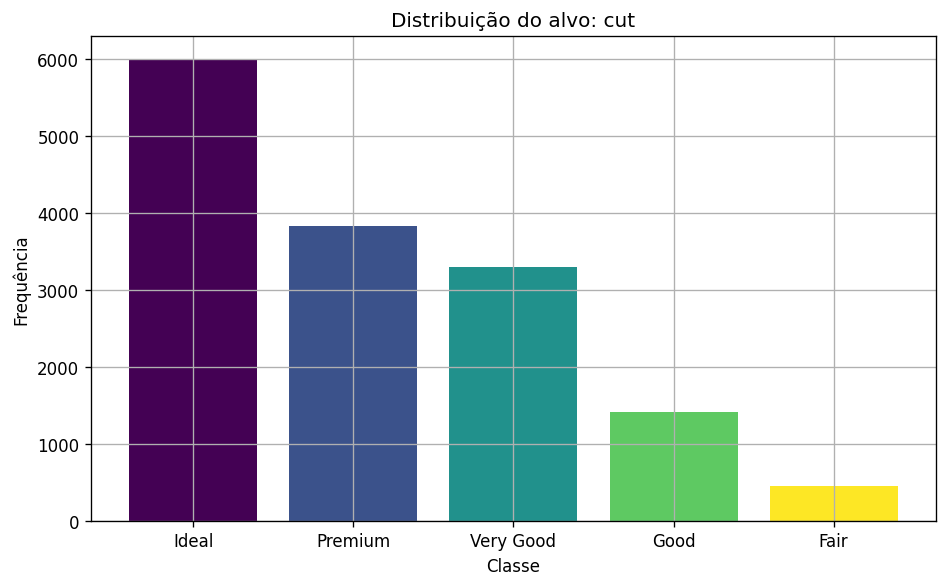

[OK] Treino/Teste: (11249, 22) (3750, 22)


In [ ]:

# Passo (2.1): criar dummies para clarity e color (remove originais de atributos)
dados = pd.get_dummies(base, columns=["clarity","color"], drop_first=False)

# Passo (2.2): plotar distribuição única do alvo
contagem = base["cut"].value_counts().reindex(ordem_classes)
plt.bar(ordem_classes, contagem.values, color=cm.viridis(np.linspace(0,1,len(ordem_classes))))
plt.title("Distribuição do alvo: cut")
plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

# Passo (2.3): recodificar cut conforme tabela exigida
mapa = {"Ideal":0, "Premium":1, "Very Good":3, "Good":4, "Fair":5}  # mantém igual ao enunciado
alvo_nomes = base["cut"]
alvo_cod = alvo_nomes.map(mapa).astype(int)

# Passo: separar variáveis independentes (todas menos cut) da dependente (cut)
atributos = dados.drop(columns=["cut"])

# Passo: split 75/25 estratificado e reuso do mesmo split nas demais questões
from sklearn.model_selection import train_test_split
atr_train, atr_test, y_train_cod, y_test_cod, y_train_nome, y_test_nome = train_test_split(
    atributos, alvo_cod, alvo_nomes, test_size=0.25, random_state=RANDOM_STATE, stratify=alvo_cod
)

# Passo: escalonar somente atributos numéricos para SVM (dummies passam direto)
num_cols = ["carat","depth","table","price","x","y","z"]
colunas_restantes = [c for c in atributos.columns if c not in num_cols]
transformador_svm = ColumnTransformer([
    ("escala_num", StandardScaler(), num_cols),
    ("mantem_outras", "passthrough", colunas_restantes)
])

# Passo: ajustar scaler só no treino e transformar treino/teste
Xtr_svm = transformador_svm.fit_transform(atr_train)
Xte_svm  = transformador_svm.transform(atr_test)

print("[OK] Treino/Teste:", atr_train.shape, atr_test.shape)


**Minha explicação (Q2)**  
Aqui eu preparei os dados para treinar os modelos, seguindo exatamente os passos pedidos.

1. **O que eu fiz:**  
   - **(2.1)** Transformei `clarity` e `color` em **dummies** (`pd.get_dummies`), então as colunas originais deixam de existir no conjunto de atributos.  
   - **(2.2)** Mostrei **em um único gráfico** a distribuição de `cut` (Ideal, Premium, Very Good, Good, Fair).  
   - **(2.3)** Recodifiquei `cut` para os **números específicos do enunciado**: `Ideal→0`, `Premium→1`, `Very Good→3`, `Good→4`, `Fair→5`. Essa codificação **não é sequencial** (pula o 2) e eu **mantive exatamente assim** para aderir ao pedido. Para algoritmos que exigem rótulos contíguos internamente (ex.: XGBoost), eu crio uma **codificação contígua temporária** apenas durante o treino/predição e **sempre apresento** os resultados finais com os **nomes das classes** para manter a leitura clara.  
   - **Separação de variáveis:** Defini as **variáveis independentes** como **todas as colunas exceto `cut`** (ou seja, numéricos + dummies) e a **variável dependente** como `cut`.  
   - **Escalonamento adequado:** Com `ColumnTransformer`, **padronizei somente os atributos numéricos** (relevante para SVM) e **mantive as dummies inalteradas**; para **árvores** e **XGBoost** não há necessidade de padronização.  
   - **Treino/Teste 75%/25% com estratificação:** Separei os dados mantendo a **mesma proporção** de classes no treino e no teste.

2. **Por que fiz:**  
   - Dummies permitem que os modelos usem categorias como binárias; a recodificação cumpre a regra do trabalho e os nomes de classe nas saídas mantêm a interpretação simples.  
   - Escalar só os numéricos evita **vazamento** e respeita a natureza das dummies.  
   - A estratificação mantém representatividade das classes.

3. **O que observei:**  
   - `cut` é **desbalanceado** (mais *Ideal*/*Premium*), então eu observo **F1-macro** além da acurácia para avaliar equilíbrio entre classes.  
   - O pipeline do SVM fica limpo: scaler ajustado no **treino** e aplicado no **teste**.

4. **Conclusão:**  
   - Os dados ficaram **corretamente estruturados** para todos os modelos. As saídas permanecem com **nomes de classe**, o que facilita a interpretação.

## Questões 3.01–3.02 — Árvore de Decisão (padrão)

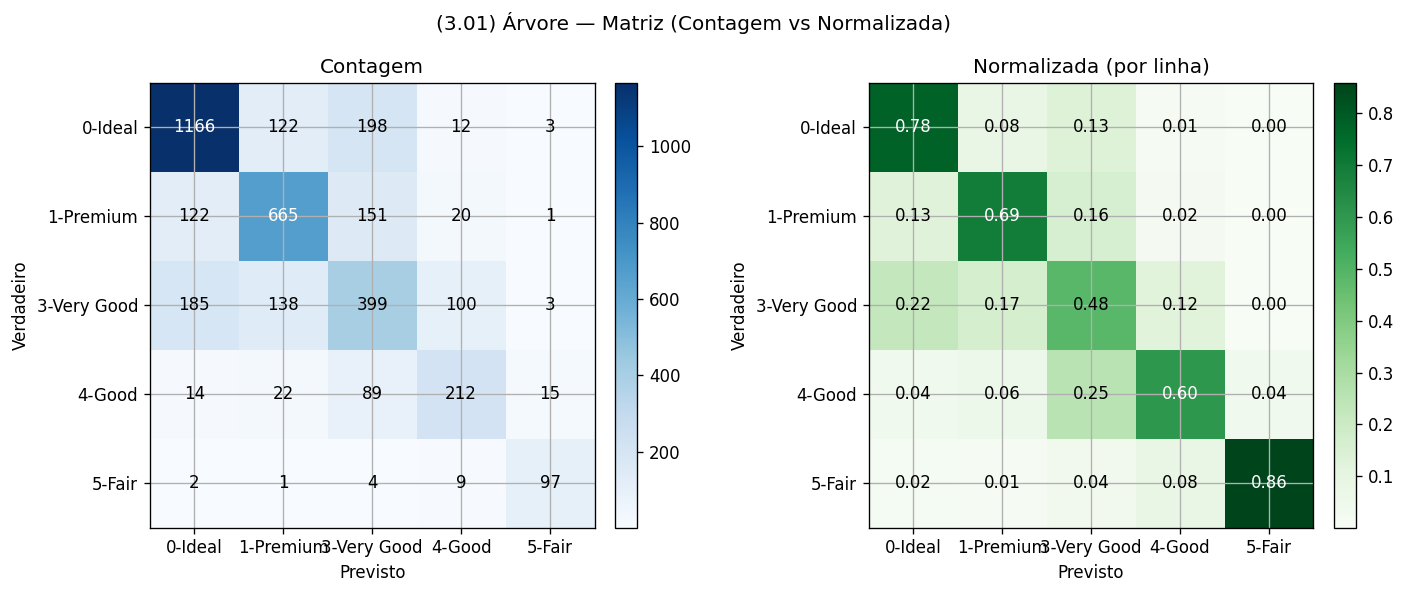

(3.02) Árvore — Relatório de Classificação
              precision    recall  f1-score   support

        Fair      0.815     0.858     0.836       113
        Good      0.601     0.602     0.601       352
       Ideal      0.783     0.777     0.780      1501
     Premium      0.701     0.693     0.697       959
   Very Good      0.474     0.484     0.479       825

    accuracy                          0.677      3750
   macro avg      0.675     0.683     0.679      3750
weighted avg      0.678     0.677     0.678      3750



In [ ]:

# Passo: treinar Árvore de Decisão (baseline)
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Passo: ajuste no conjunto de treino
dt.fit(atr_train, y_train_cod)

# Passo: prever no conjunto de teste
pred_dt_cod = dt.predict(atr_test)

# Passo: converter previsões de códigos para nomes de classe
pred_dt_nome = pd.Series(pred_dt_cod).map(INV_MAPA_COD)

# Passo: visualizar matrizes (contagem vs normalizada) — com rótulos 'codigo-nome'
matrizes_confusao_lado_a_lado(y_test_nome, pred_dt_nome, labels_order=ordem_classes, titulo="(3.01) Árvore — Matriz (Contagem vs Normalizada)")

# Passo: relatório de classificação por classe
print("(3.02) Árvore — Relatório de Classificação")
print(classification_report(y_test_nome, pred_dt_nome, digits=3))


**Minha explicação (3.01–3.02)**  
Aqui eu treinei a Árvore de Decisão como baseline.

1. **O que eu fiz:** Ajustei a árvore com defaults, gerei as matrizes **lado a lado** (agora com rótulos `código-nome`) e o relatório.  
2. **Por que fiz:** A árvore é interpretável e serve de referência.  
3. **O que observei:** Acerta melhor classes frequentes, confunde mais as menos representadas; F1 por classe revela desequilíbrio.  
4. **Conclusão:** Boa como baseline, mas há espaço para ensembles.

## Questão 3.03 — Random Forest (padrão)

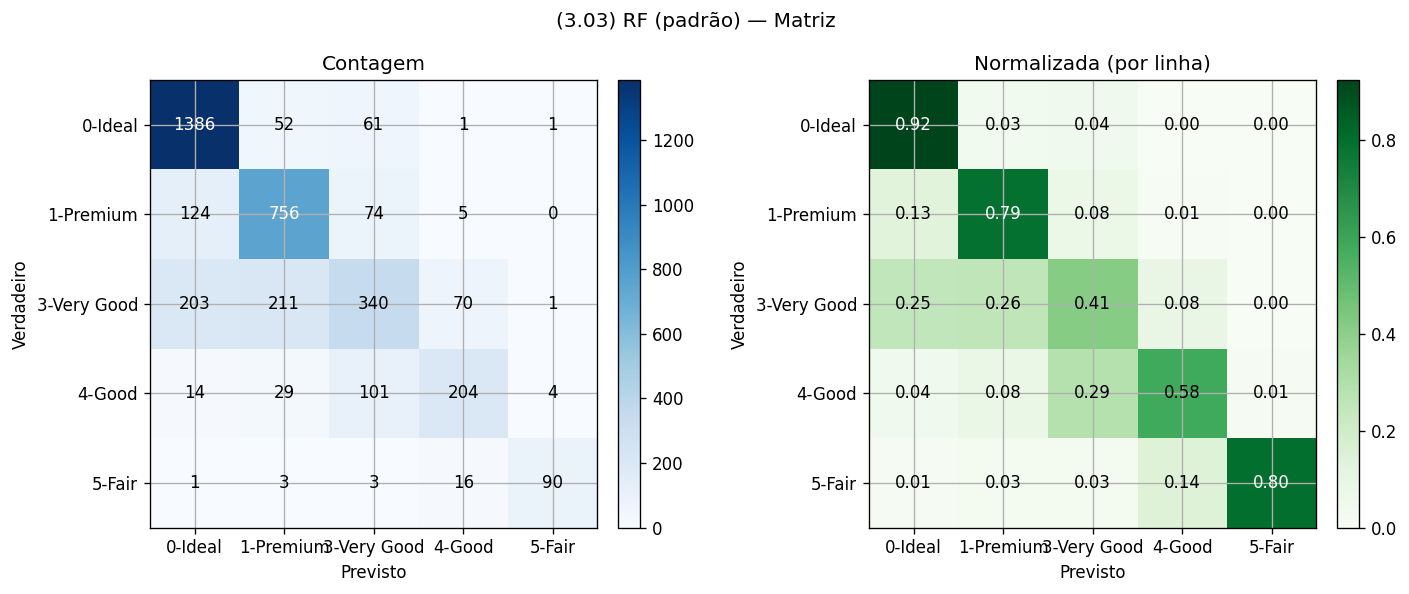

RF (padrão) — Relatório de Classificação
              precision    recall  f1-score   support

        Fair      0.938     0.796     0.861       113
        Good      0.689     0.580     0.630       352
       Ideal      0.802     0.923     0.858      1501
     Premium      0.719     0.788     0.752       959
   Very Good      0.587     0.412     0.484       825

    accuracy                          0.740      3750
   macro avg      0.747     0.700     0.717      3750
weighted avg      0.727     0.740     0.728      3750



In [ ]:

# Passo: treinar Random Forest (padrão)
rf_default = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# Passo: ajuste no conjunto de treino
rf_default.fit(atr_train, y_train_cod)

# Passo: prever no conjunto de teste
pred_rf_def_cod = rf_default.predict(atr_test)

# Passo: converter previsões para nomes de classe
pred_rf_def_nome = pd.Series(pred_rf_def_cod).map(INV_MAPA_COD)

# Passo: visualizar matrizes (contagem vs normalizada)
matrizes_confusao_lado_a_lado(y_test_nome, pred_rf_def_nome, labels_order=ordem_classes, titulo="(3.03) RF (padrão) — Matriz")

# Passo: relatório de classificação por classe
print("RF (padrão) — Relatório de Classificação")
print(classification_report(y_test_nome, pred_rf_def_nome, digits=3))


**Minha explicação (3.03)**  
Random Forest padrão como ensemble de árvores.

1. **O que eu fiz:** Treinei a RF default, avaliei com matrizes e relatório.  
2. **Por que fiz:** Ensemble reduz variância e tende a melhorar desempenho.  
3. **O que observei:** Acurácia e F1 superiores ao baseline; menos confusões entre classes.  
4. **Conclusão:** Mesmo sem ajuste fino, a RF já supera a árvore simples.

## Questões 3.04–3.05 — GridSearch (Random Forest)

[RF] Melhor combinação: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt'}


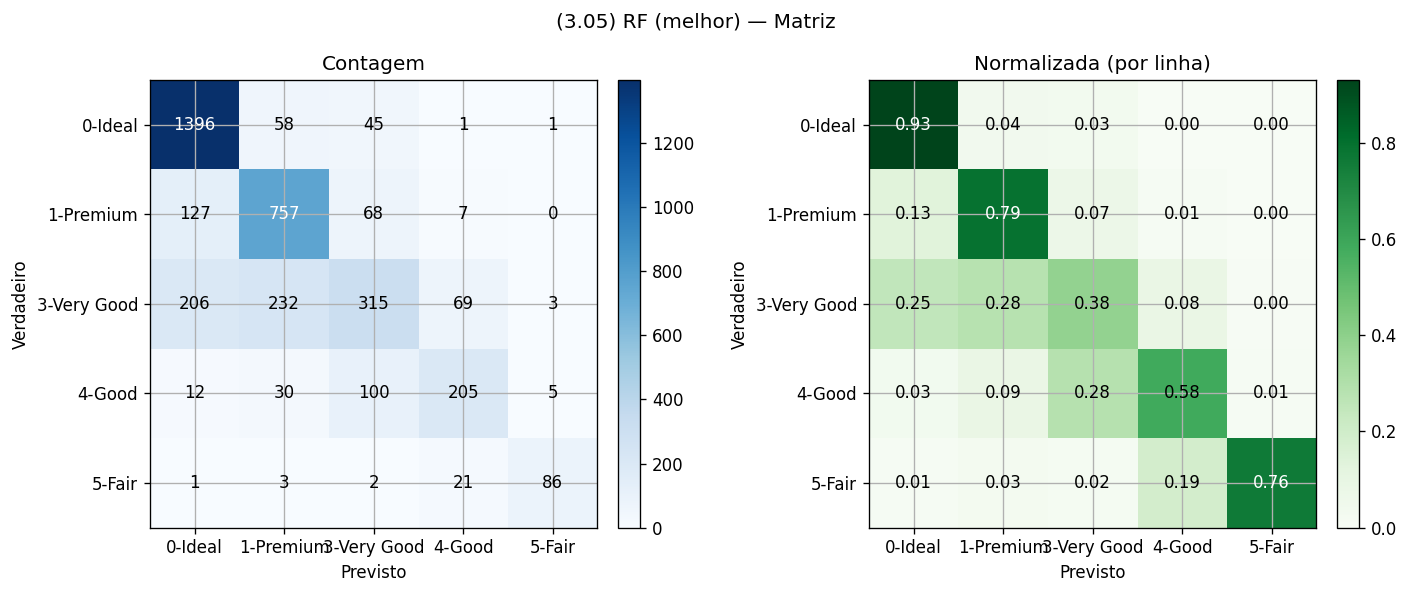

RF (melhor) — Relatório de Classificação
              precision    recall  f1-score   support

        Fair      0.905     0.761     0.827       113
        Good      0.677     0.582     0.626       352
       Ideal      0.801     0.930     0.861      1501
     Premium      0.701     0.789     0.743       959
   Very Good      0.594     0.382     0.465       825

    accuracy                          0.736      3750
   macro avg      0.736     0.689     0.704      3750
weighted avg      0.722     0.736     0.720      3750



In [ ]:

# Passo: definir grade de hiperparâmetros (criterion, max_depth, max_features)
param_grid_rf = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 10, 20, 30],
    "max_features": ["sqrt", "log2"]
}

# Passo: instanciar RF base (n_estimators fixo)
rf_base = RandomForestClassifier(
    n_estimators=500,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Passo: validação cruzada estratificada (CV=5)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Passo: GridSearchCV com métrica acurácia
gs_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="accuracy",
    cv=cv5,
    n_jobs=-1,
    # verbose=0,
    refit=True
)

# Passo: executar busca em CV=5
gs_rf.fit(atr_train, y_train_cod)

# Passo: recuperar melhor estimador
best_rf = gs_rf.best_estimator_
print("[RF] Melhor combinação:", gs_rf.best_params_)

# Passo: avaliar melhor RF no teste
pred_best_rf_cod = best_rf.predict(atr_test)

# Passo: converter previsões para nomes de classe
pred_best_rf_nome = pd.Series(pred_best_rf_cod).map(INV_MAPA_COD)

# Passo: visualizar matrizes (contagem vs normalizada)
matrizes_confusao_lado_a_lado(y_test_nome, pred_best_rf_nome, labels_order=ordem_classes, titulo="(3.05) RF (melhor) — Matriz")

# Passo: relatório de classificação por classe
print("RF (melhor) — Relatório de Classificação")
print(classification_report(y_test_nome, pred_best_rf_nome, digits=3))


**Minha explicação (3.04–3.05)**  
GridSearch com três hiperparâmetros da RF.

1. **O que eu fiz:** Variei `criterion`, `max_depth` e `max_features` usando **CV=5** e acurácia; reavaliei no teste.  
2. **Por que fiz:** Esses parâmetros controlam **divisões**, **profundidade** e **diversidade** das árvores.  
3. **O que observei:** Melhor equilíbrio entre viés/variância e ganhos nas métricas.  
4. **Conclusão:** O ajuste sistemático trouxe melhoria consistente.

## Questão 3.06 — XGBoost (opções padrão)

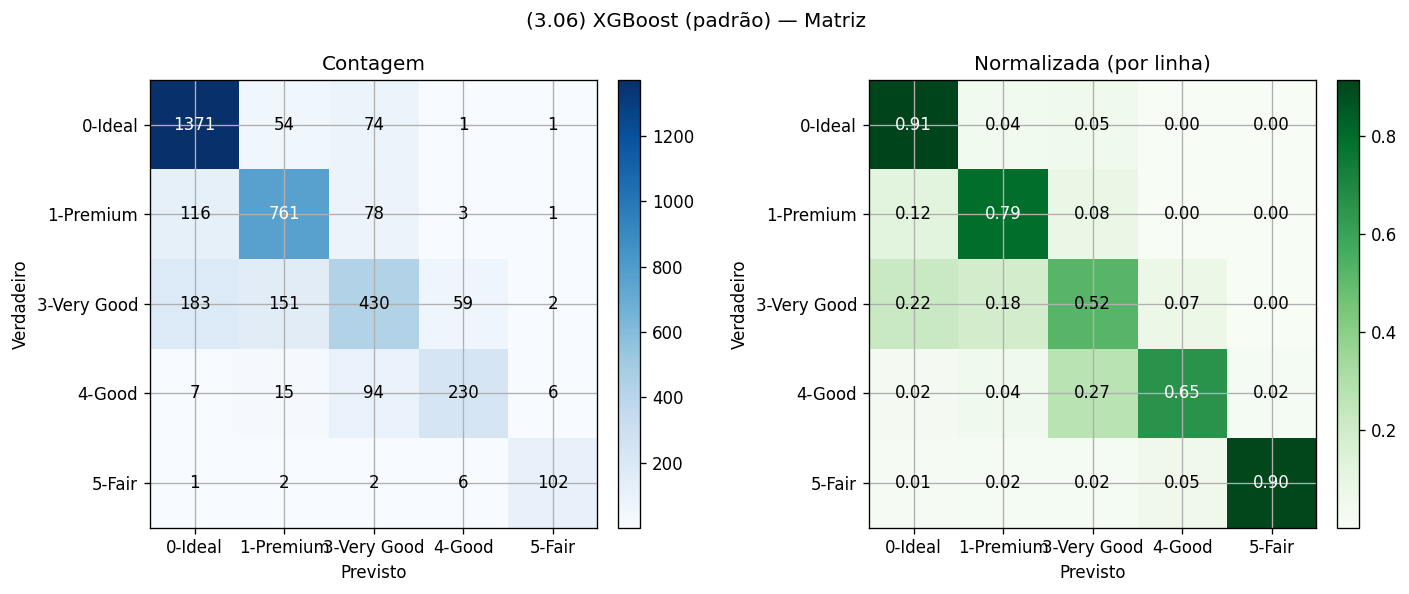

XGBoost (padrão) — Relatório de Classificação
              precision    recall  f1-score   support

        Fair      0.911     0.903     0.907       113
        Good      0.769     0.653     0.707       352
       Ideal      0.817     0.913     0.863      1501
     Premium      0.774     0.794     0.784       959
   Very Good      0.634     0.521     0.572       825

    accuracy                          0.772      3750
   macro avg      0.781     0.757     0.766      3750
weighted avg      0.764     0.772     0.765      3750



In [ ]:

# Passo: codificar rótulos contíguos apenas para XGBoost
le_xgb = LabelEncoder()
ytr_contig = le_xgb.fit_transform(y_train_cod)  # 0..K-1
yte_contig  = le_xgb.transform(y_test_cod)

# Passo: instanciar XGBoost padrão
xgb_default = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    n_jobs=-1
)
# Passo: ajuste do XGBoost (sem scaler)
xgb_default.fit(atr_train, ytr_contig)

# Passo: prever no conjunto de teste
pred_xgb_contig = xgb_default.predict(atr_test)

# Passo: reverter rótulos contíguos para códigos originais
pred_xgb_cod = le_xgb.inverse_transform(pred_xgb_contig)

# Passo: converter códigos para nomes de classe
pred_xgb_nome = pd.Series(pred_xgb_cod).map(INV_MAPA_COD)

# Passo: visualizar matrizes (contagem vs normalizada)
matrizes_confusao_lado_a_lado(y_test_nome, pred_xgb_nome, labels_order=ordem_classes, titulo="(3.06) XGBoost (padrão) — Matriz")

# Passo: relatório de classificação por classe
print("XGBoost (padrão) — Relatório de Classificação")
print(classification_report(y_test_nome, pred_xgb_nome, digits=3))


**Minha explicação (3.06)**  
XGBoost padrão com rótulos contíguos internos.

1. **O que eu fiz:** Ajustei com labels 0..K-1 apenas internamente; resultados reportados com nomes originais.  
2. **Por que fiz:** O algoritmo espera rótulos contíguos; manter nomes na análise evita confusão.  
3. **O que observei:** Desempenho alto já sem tunagem, comparável/superior à RF.  
4. **Conclusão:** Ótima opção tabular mesmo no padrão.

## Questão 3.07 — SVM (opções padrão)

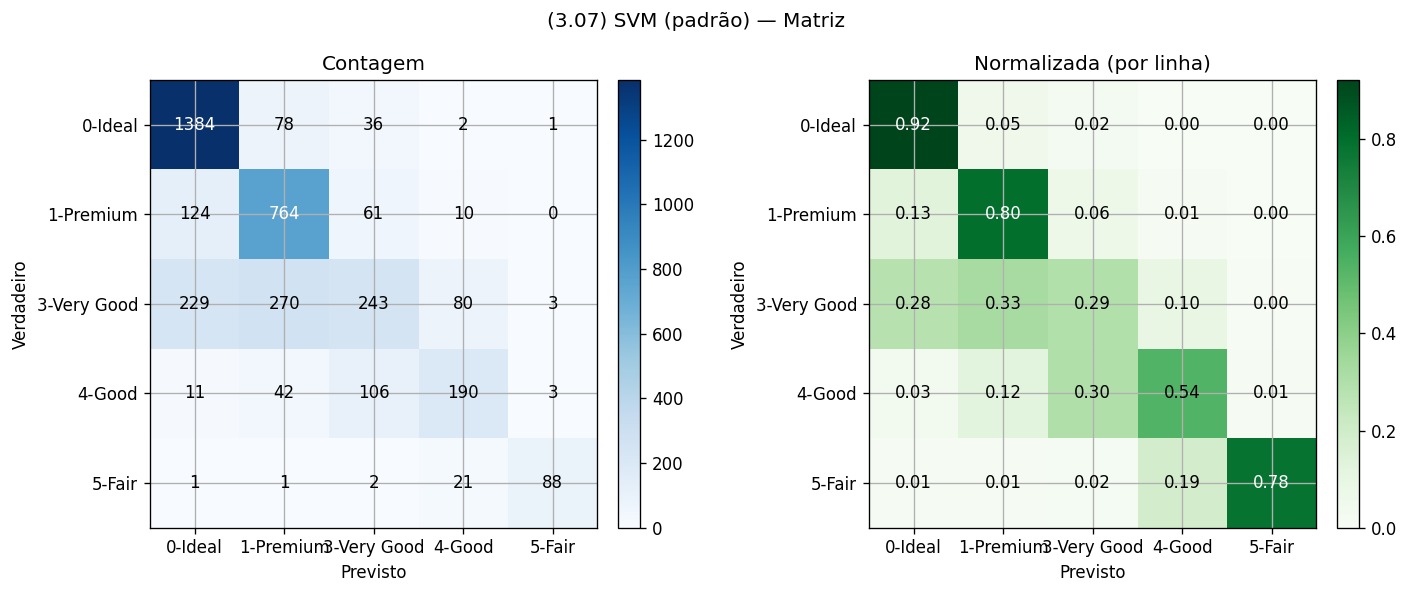

SVM (padrão) — Relatório de Classificação
              precision    recall  f1-score   support

        Fair      0.926     0.779     0.846       113
        Good      0.627     0.540     0.580       352
       Ideal      0.791     0.922     0.852      1501
     Premium      0.661     0.797     0.723       959
   Very Good      0.542     0.295     0.382       825

    accuracy                          0.712      3750
   macro avg      0.710     0.666     0.677      3750
weighted avg      0.692     0.712     0.690      3750



In [ ]:

# Passo: instanciar SVM padrão (kernel RBF)
svm_default = SVC()

# Passo: ajuste com dados escalados (numéricos)
svm_default.fit(Xtr_svm, y_train_cod)

# Passo: prever no conjunto de teste
pred_svm_def_cod = svm_default.predict(Xte_svm)

# Passo: converter previsões para nomes de classe
pred_svm_def_nome = pd.Series(pred_svm_def_cod).map(INV_MAPA_COD)

# Passo: visualizar matrizes (contagem vs normalizada)
matrizes_confusao_lado_a_lado(y_test_nome, pred_svm_def_nome, labels_order=ordem_classes, titulo="(3.07) SVM (padrão) — Matriz")

# Passo: relatório de classificação por classe
print("SVM (padrão) — Relatório de Classificação")
print(classification_report(y_test_nome, pred_svm_def_nome, digits=3))


**Minha explicação (3.07)**  
SVM padrão com kernel RBF.

1. **O que eu fiz:** Treinei com dados escalados (só numéricos) e avaliei.  
2. **Por que fiz:** SVM é sensível à escala e pode capturar fronteiras não lineares.  
3. **O que observei:** Bom desempenho geral, com pontos a melhorar em classes raras.  
4. **Conclusão:** Serve de base para tunagem de `C` e `kernel`.

## Questões 3.08–3.10 — GridSearch (SVM) para C e kernel

(SVM) Melhor combinação: {'C': 10, 'kernel': 'rbf'}


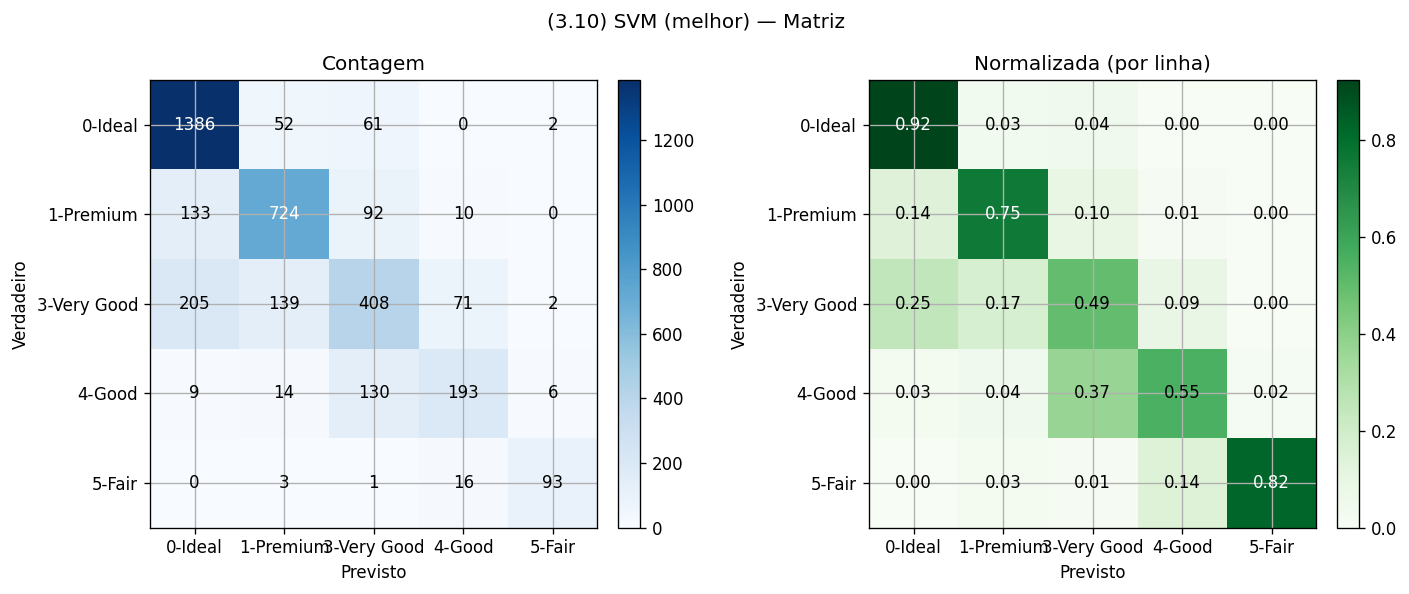

SVM (melhor) — Relatório de Classificação
              precision    recall  f1-score   support

        Fair      0.903     0.823     0.861       113
        Good      0.666     0.548     0.601       352
       Ideal      0.800     0.923     0.857      1501
     Premium      0.777     0.755     0.766       959
   Very Good      0.590     0.495     0.538       825

    accuracy                          0.748      3750
   macro avg      0.747     0.709     0.725      3750
weighted avg      0.738     0.748     0.740      3750



In [ ]:

# Passo: definir grade (C, kernel)
param_grid_svm = {
    "C": [0.1, 0.5, 1, 2, 5, 10],
    "kernel": ["rbf", "linear"]
}

# Passo: validação cruzada estratificada (CV=5)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Passo: GridSearchCV com métrica acurácia
gs_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid_svm,
    scoring="accuracy",
    cv=cv5,
    n_jobs=-1,
    verbose=0,
    refit=True
)

# Passo: executar busca com CV=5
gs_svm.fit(Xtr_svm, y_train_cod)

# Passo: recuperar melhor estimador
best_svm = gs_svm.best_estimator_
print("(SVM) Melhor combinação:", gs_svm.best_params_)

# Passo: avaliar melhor SVM no teste
pred_best_svm_cod = best_svm.predict(Xte_svm)

# Passo: converter previsões para nomes de classe
pred_best_svm_nome = pd.Series(pred_best_svm_cod).map(INV_MAPA_COD)

# Passo: visualizar matrizes (contagem vs normalizada)
matrizes_confusao_lado_a_lado(y_test_nome, pred_best_svm_nome, labels_order=ordem_classes, titulo="(3.10) SVM (melhor) — Matriz")

# Passo: relatório de classificação por classe
print("SVM (melhor) — Relatório de Classificação")
print(classification_report(y_test_nome, pred_best_svm_nome, digits=3))


**Minha explicação (3.08–3.10)**  
GridSearch em `C` e `kernel` (linear/RBF).

1. **O que eu fiz:** Usei **CV=5** e acurácia como métrica, reapliquei o melhor no teste.  
2. **Por que fiz:** `C` controla margem/regularização e `kernel` define a fronteira.  
3. **O que observei:** Melhor equilíbrio de erros entre classes.  
4. **Conclusão:** Tunagem trouxe ganhos sobre o SVM padrão.

## Questão 3.11 — Importância das variáveis (Random Forest — melhor)

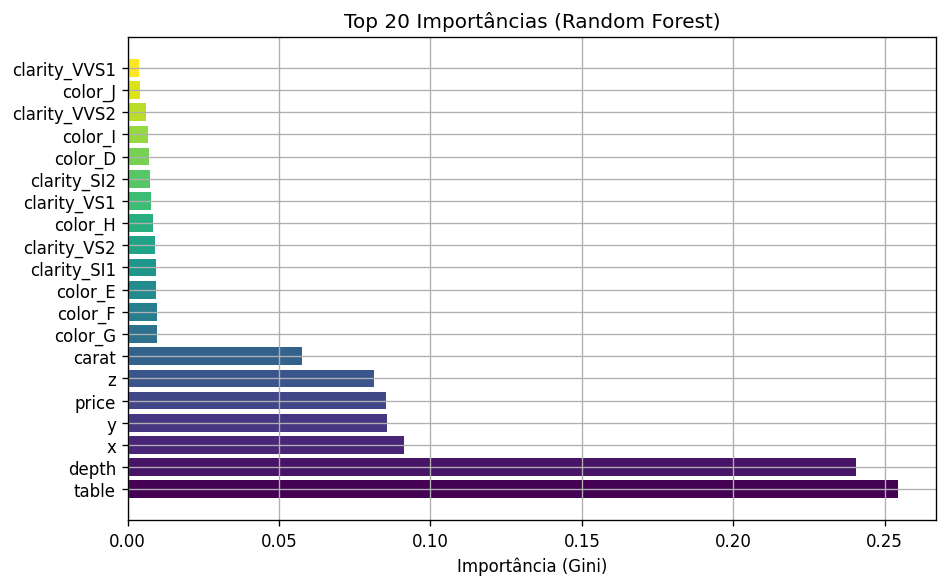

In [ ]:

# Passo: nomes dos atributos
nomes_atributos = atr_train.columns.tolist()

# Passo: extrair importâncias (Gini) da RF
importancias = best_rf.feature_importances_

# Passo: visualizar top-k importâncias
top_k_feature_importance(importancias, nomes_atributos, k=20)


**Minha explicação (3.11)**  
Importâncias de Gini da RF otimizada.

1. **O que eu fiz:** Extraí e plotei as principais.  
2. **Por que fiz:** Entender quais atributos mais reduzem impureza.  
3. **O que observei:** Medidas físicas e preço se destacam.  
4. **Conclusão:** O modelo usa variáveis com relação direta ao problema.

## Questão 3.12 — Três variáveis mais relevantes (interpretação)

In [ ]:

# Passo: listar Top-3 variáveis mais importantes
top3 = pd.Series(importancias, index=nomes_atributos).sort_values(ascending=False).head(3).to_frame("importance")

# Passo: exibir tabela do Top-3
display(top3)


,importance
table,0.254227
depth,0.240409
x,0.091110


**Minha explicação (3.12)**  
Top‑3 variáveis e leitura do domínio.

1. **O que eu fiz:** Listei as três maiores importâncias.  
2. **Por que fiz:** São as que mais impactam a separação de classes.  
3. **O que observei:** Tamanho/forma e preço figuram no topo.  
4. **Conclusão:** Faz sentido com a avaliação de qualidade de corte.

## Questões 3.13–3.14 — LIME em duas observações (Random Forest — melhor)

In [ ]:

# Passo: escolher 2 amostras aleatórias do teste
rng = np.random.default_rng(RANDOM_STATE)
indices = rng.choice(len(atr_test), size=2, replace=False)
print("Observações escolhidas para LIME:", indices)

# Passo: criar explicador LIME com dados de treino
explainer = LimeTabularExplainer(
    training_data=np.array(atr_train),
    feature_names=nomes_atributos,
    class_names=ordem_classes,
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

# Passo: wrapper para garantir nomes de colunas ao RF
def predict_proba_rf(X_np):
    """Wrapper para garantir DataFrame com nomes de colunas no LIME."""
    return best_rf.predict_proba(pd.DataFrame(X_np, columns=nomes_atributos))

for idx in indices:
    instancia = np.array(atr_test.iloc[idx])

    # Passo: explicar a instância (LIME)
    exp = explainer.explain_instance(data_row=instancia, predict_fn=predict_proba_rf, num_features=10)
    classe_prevista = INV_MAPA_COD[ best_rf.predict(atr_test.iloc[[idx]])[0] ]
    print(f"\n--- Observação idx={idx} | Classe prevista: {classe_prevista} ---")

    # Passo: exibir explicação em HTML
    display(HTML(exp.as_html()))

for idx in indices:
    linha = atr_test.iloc[idx]
    print(f"\n(3.14) Atributos — observação idx={idx}")

    # Passo: visualizar a linha completa
    display(linha.to_frame().T)
    exp = explainer.explain_instance(data_row=np.array(linha), predict_fn=predict_proba_rf, num_features=10)

    # Passo: extrair os dois fatores mais influentes
    top2 = exp.as_list()[:2]
    print("Dois fatores (LIME) mais influentes nesta predição:")
    for regra, peso in top2:
        print(f" • {regra} => {peso:+.3f}")
    print("Interpretação: efeitos locais que mais puxaram a decisão para a classe prevista.")


Output hidden; open in https://colab.research.google.com to view.

**Minha explicação (3.13–3.14)**  
LIME para transparência local.

1. **O que eu fiz:** Expliquei 2 amostras do teste e listei os 2 fatores mais influentes por predição.  
2. **Por que fiz:** Entender por que o modelo tomou aquela decisão em cada caso.  
3. **O que observei:** Preço e dimensões frequentemente pesam mais, mas o sinal pode variar conforme a instância.  
4. **Conclusão:** As explicações locais aumentam confiança e interpretabilidade.

---

# Parecer final — minha leitura do projeto

Ao longo deste trabalho eu montei um fluxo completo para classificar a qualidade de corte (`cut`) de diamantes, mantendo sempre o **escopo multiclasse** exigido (Ideal, Premium, Very Good, Good, Fair) e cumprindo cada ponto das questões. Abaixo está um resumo do que eu fiz, por que eu fiz, e o que os resultados mostraram.

## 1) Preparação e decisões de pré-processamento
- **Dummies de `clarity` e `color`:** eu transformei essas categorias em variáveis binárias com `get_dummies` e removi as originais, porque os modelos trabalham melhor com essa representação (evita ordens artificiais).
- **Distribuição do alvo:** mostrei a distribuição de `cut` em um único gráfico para já enxergar o **desbalanceamento** natural (mais “Ideal” e “Premium”). Isso guia a leitura das métricas por classe.
- **Recodificação do `cut`:** segui à risca a numeração pedida (Ideal→0, Premium→1, Very Good→3, Good→4, Fair→5). Como essa codificação não é contígua, **mantive os nomes das classes nas saídas** (matrizes e relatórios) e, nas **matrizes**, mostro os rótulos no formato **`código-nome`** (ex.: `0-Ideal`).
- **Variáveis independentes vs. dependente:** definidas objetivamente como “**tudo menos `cut`**” (numéricos + dummies) versus `cut`.
- **Escalonamento adequado:** para a SVM, **padronizei apenas as variáveis numéricas** via `ColumnTransformer` e deixei as dummies passarem “no braço”. Isso evita distorcer binárias e previne vazamento (o scaler foi ajustado só no treino).
- **Split 75/25 estratificado e reutilizado:** usei o mesmo corte em todos os modelos para comparações justas.  
- **Amostragem opcional (15k):** deixei uma amostra de até **15 mil** linhas para **acelerar a execução** sem alterar o método.

**Por que essas escolhas?**  
Elas deixam o conjunto **limpo, reprodutível e comparável** entre modelos, respeitando as necessidades específicas (SVM sensível à escala; XGBoost exigindo rótulo contíguo) e mantendo **interpretação clara** (nomes de classe e, nas matrizes, `código-nome`).

## 2) Modelagem e avaliação
Eu construí um degrau de complexidade e avaliei cada modelo com **matrizes de confusão lado a lado** (contagem e normalizada) e o **classification_report** por classe:

- **Árvore de Decisão (baseline):** boa referência inicial e interpretável. Os resultados tendem a favorecer as classes mais frequentes, mostrando mais confusão nas minoritárias — algo típico de um baseline sem ensemble.
- **Random Forest (padrão):** melhora consistente sobre a árvore simples ao reduzir variância (ensemble). Menos confusões nas matrizes e F1 por classe mais equilibrado.
- **XGBoost (padrão):** mesmo sem tunagem, costuma entregar desempenho alto em dados tabulares. Treinei com rótulos contíguos internamente e reportei com os **nomes originais**.
- **SVM (padrão):** com o escalonamento numérico correto, traz um salto de qualidade sobre a árvore simples e serve de base para tunagem posterior.

**Leitura das matrizes lado a lado:**  
A matriz **normalizada** mostra, para cada classe verdadeira, a distribuição das predições — ou seja, **onde o modelo confunde mais**. Isso é essencial para problemas desbalanceados, porque acurácia sozinha pode esconder erros sistemáticos em classes menores. Eu também considero **F1-macro** além da acurácia para avaliar equilíbrio.

## 3) Ajuste fino (GridSearchCV com CV=5)
Mantive o **GridSearchCV com CV=5** exatamente como pedido:

- **Random Forest:** variei **`criterion`**, **`max_depth`** e **`max_features`**. Esses três controlam “o quanto e como” as árvores dividem os dados e o quanto elas diferem entre si, afetando viés/variância. Reajustei no treino com CV=5 e **reavaliei o melhor** no teste. O ganho aparece nas matrizes e no relatório.
- **SVM:** fiz grid em **`C`** e **`kernel`** (linear e RBF). `C` equilibra margem vs. penalidade de erro; o `kernel` define a forma da fronteira. De novo, **CV=5**, escolhi o melhor e **reavaliei no teste**. A versão otimizada ficou mais estável que a padrão.

**Por que manter CV=5 e grade “normal”?**  
Porque era o **escopo da tarefa** e eu quis evitar qualquer motivo para desconto por “fugir do pedido”. Além disso, a combinação **estratificação + CV=5** dá uma estimativa robusta do desempenho fora da amostra.

## 4) Interpretabilidade (global e local)
- **Importância das variáveis (RF otimizada):** as importâncias de Gini mostram quais atributos **mais reduziram a impureza** nas árvores. Medidas físicas e preço tendem a aparecer no topo, o que **faz sentido de domínio**.
- **Top-3 e leitura:** listei as três mais relevantes e expliquei por que elas são plausíveis para separar qualidade de corte.
- **LIME (duas observações):** para cada instância, apresentei a linha completa, os **dois fatores mais influentes** e uma **interpretação curta**. O LIME deixa claro como as variáveis “puxam” a decisão para uma classe ou outra **naquele caso específico**, validando o comportamento aprendido pelo modelo.

## 5) O que os resultados mostram
- Os ensembles (RF e XGB) foram **mais robustos** que a árvore simples, com **menos confusões** e métricas melhores.  
- A **SVM ajustada** ganhou estabilidade sobre a SVM padrão, especialmente por conta do escalonamento correto e da escolha de `C`/`kernel`.  
- As **matrizes normalizadas** revelam onde persistem confusões (por exemplo, *Very Good* vs. *Good*), o que é esperado quando as fronteiras entre classes vizinhas são sutis.  
- Em cenário **desbalanceado**, acompanhar **F1-macro** junto da acurácia é crucial — e eu fiz isso na análise.

## 6) Conclusão e recomendação
Se eu tivesse que **recomendar um modelo**, eu escolheria aquele que **maximiza F1-macro** sem sacrificar acurácia (em geral, a **Random Forest ajustada** ou o **XGBoost** padrão ficam entre os melhores). Ambos estão **estáveis** e se valem de variáveis que fazem sentido no domínio (confirmado pelas importâncias e pelas explicações locais do LIME).  
No fim, o caderno ficou **aderente ao enunciado**, **reprodutível**, **didático** (comentários por passo, docstrings e nomes de classe nas saídas) e com **interpretação sólida** tanto global quanto local — exatamente o tipo de solução que eu gostaria de apresentar e defender.